## Data Aggrigation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv('drugsComTrain_raw.csv')
df_test = pd.read_csv('drugsComTest_raw.csv')

In [3]:
data = pd.concat([df_train,df_test])

In [4]:
data.sample(30)

,uniqueID,drugName,condition,review,rating,date,usefulCount
30316,129068,Levonorgestrel,Emergency Contraception,"""Hi ladies im here to share my experience wuth...",8,10-Nov-15,14
127033,108551,Bupropion / naltrexone,Obesity,"""I&#039;ve been on Contrave for almost 2 weeks...",4,24-Dec-14,21
34652,215701,Copper,Birth Control,"""I&#039;m 25 with two kids. I had my insertion...",1,24-Mar-17,3
32598,146889,Alprazolam,Depression,"""I agree with everything that has already been...",10,10-Mar-16,74
16641,184726,Canagliflozin,"Diabetes, Type 2","""Started taking Invokana a little over a year ...",8,20-Apr-16,25
153243,13045,Dapsone,Linear IgA Disease,"""I have been taking dapsone since December 200...",10,4-Apr-12,9
55583,6516,Sodium biphosphate / sodium phosphate,Constipation,"""So good that I went on the internet and wrote...",10,14-Oct-17,1
51271,212517,Lysine,Herpes Simplex,"""I hsve HSV1 on geitals from oral sex. I was ...",10,12-Apr-16,10
80481,66154,Propranolol,Migraine Prevention,"""This medicine has helped my migraines signifi...",9,31-Dec-09,71
161179,224499,Levothyroxine,Hashimoto's disease,"""I started on Tirosint when they stopped makin...",10,10-Nov-14,63


In [5]:
df = data.copy()

In [6]:
df.sample(10)

,uniqueID,drugName,condition,review,rating,date,usefulCount
126252,105708,Methylprednisolone,Osteoarthritis,"""The medication was a wonder drug and I was ab...",9,4-Sep-09,28
85144,203382,Indomethacin,"Gout, Acute","""Have had several bouts of gout and the pain i...",9,19-Oct-15,23
29272,11245,Drospirenone / ethinyl estradiol / levomefolat...,Acne,"""I was originally on Yaz, cleared up skin in 3...",7,5-Dec-11,4
23916,41700,Clonidine,Opiate Withdrawal,"""I was hooked on pain meds after a surgery. It...",10,9-Nov-15,63
12757,81071,Hypercare,Hyperhidrosis,"""I&#039;ve read pages of these reviews after a...",10,22-Feb-12,1
19854,86491,Invokana,"Diabetes, Type 2","""Invokana 100 mg daily in addition to Metform...",10,14-Dec-16,12
46462,147170,Alprazolam,Panic Disorde,"""I have panic disorder when I&#039;m under str...",9,9-Aug-13,82
22023,41289,Acetaminophen / oxycodone,Chronic Pain,"""I use it for back pain...it works okay for th...",7,19-Jan-13,23
158055,17434,Ethinyl estradiol / etonogestrel,Birth Control,"""Honestly, it is a pretty effective birth cont...",4,7-Mar-17,5
149126,139445,Armodafinil,Depression,"""My psychiatrist initially prescribed Nuvigil ...",10,26-Aug-11,20


From initial observation, I can say that condition and review column consists of invalid char so it need to be cleaned

## Basic anaysis

In [7]:
df.shape

(215063, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 215063 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     215063 non-null  int64 
 1   drugName     215063 non-null  object
 2   condition    213869 non-null  object
 3   review       215063 non-null  object
 4   rating       215063 non-null  int64 
 5   date         215063 non-null  object
 6   usefulCount  215063 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 13.1+ MB


Data column is in string format. It need to be converted into date format

In [9]:
df.describe()

,uniqueID,rating,usefulCount
count,215063.000000,215063.000000,215063.000000
mean,116039.364814,6.990008,28.001004
std,67007.913366,3.275554,36.346069
min,0.000000,1.000000,0.000000
25%,58115.500000,5.000000,6.000000
50%,115867.000000,8.000000,16.000000
75%,173963.500000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [10]:
df.isnull().sum()

uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

There are 1194 rows are null values in condition column

In [12]:
df.corr(numeric_only=True)

,uniqueID,rating,usefulCount
uniqueID,1.000000,0.016336,0.017567
rating,0.016336,1.000000,0.234860
usefulCount,0.017567,0.234860,1.000000


## Univariate analysis

In [13]:
from wordcloud import WordCloud, STOPWORDS

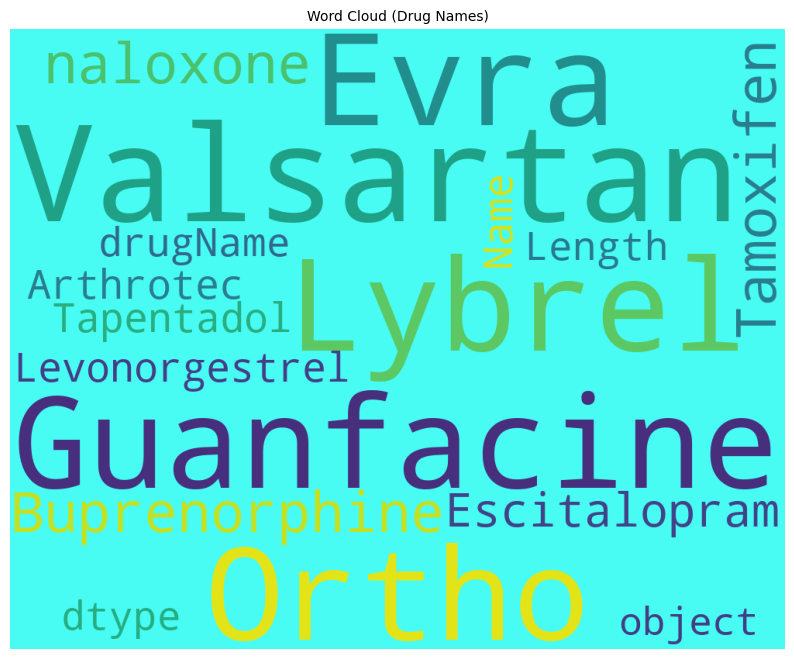

In [14]:
wordcloud = WordCloud(stopwords=set(STOPWORDS),
                      background_color='rgb(73, 252, 243)',
                      height=800,
                      width=1000
).generate(str(df['drugName']))


plt.figure(figsize=(10,10))
plt.title('Word Cloud (Drug Names)', fontsize = 10)
plt.axis("off")
plt.imshow(wordcloud)

The above cloud includes the metadata as well like dtype, Length etc. Because the str(pd.Series) includes meta data as well

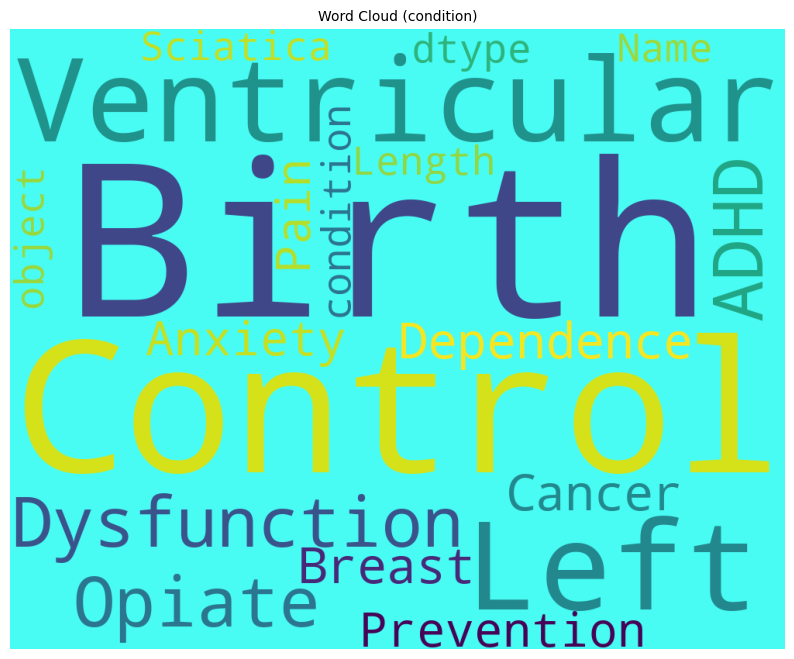

In [15]:
wordcloud = WordCloud(stopwords=set(STOPWORDS),
                      background_color='rgb(73, 252, 243)',
                      height=800,
                      width=1000
).generate(str(df['condition']))


plt.figure(figsize=(10,10))
plt.title('Word Cloud (condition)', fontsize = 10)
plt.axis("off")
plt.imshow(wordcloud)

Most of the times, we can see the birth control, ADHD, Ventricular etc

<Axes: ylabel='count'>

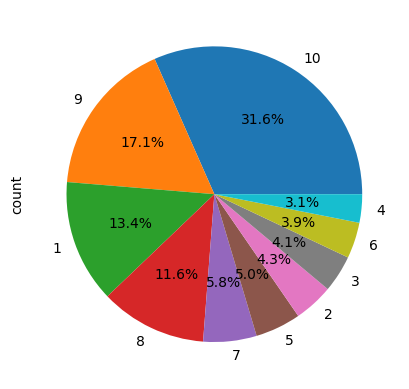

In [16]:
df['rating'].value_counts().plot(kind='pie',autopct='%1.1f%%')

<Axes: xlabel='rating', ylabel='Density'>

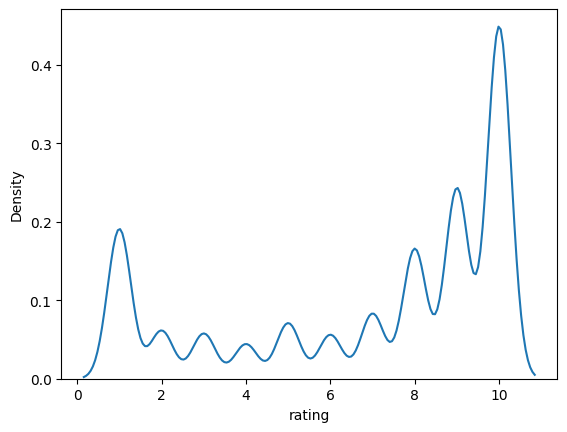

In [17]:
sns.kdeplot(df['rating'])

Most of the ratings are higher ratings ie 10, 9, 8. Some drugs about 13% also got worst rating 1

In [18]:
print((df['rating'] > 5).sum())
print((df['rating'] <= 5).sum())

150768
64295


Data is imbalance by a huge difference. May be the data includes so much of positive drugs. Hence the model may not perform well on negative drugs so well

## Bivariante analysis

C:\Users\91939\AppData\Local\Temp\ipykernel_18776\3663489246.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


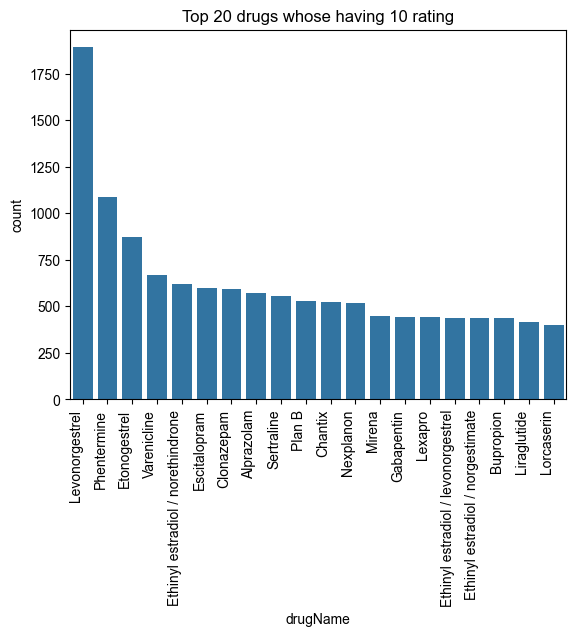

In [19]:
top_drugs_10 = df[df['rating'] == 10]['drugName'].value_counts().head(20)
bar=sns.barplot(top_drugs_10)
bar.set_title('Top 20 drugs whose having 10 rating')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [17, 5]

C:\Users\91939\AppData\Local\Temp\ipykernel_18776\1902578690.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


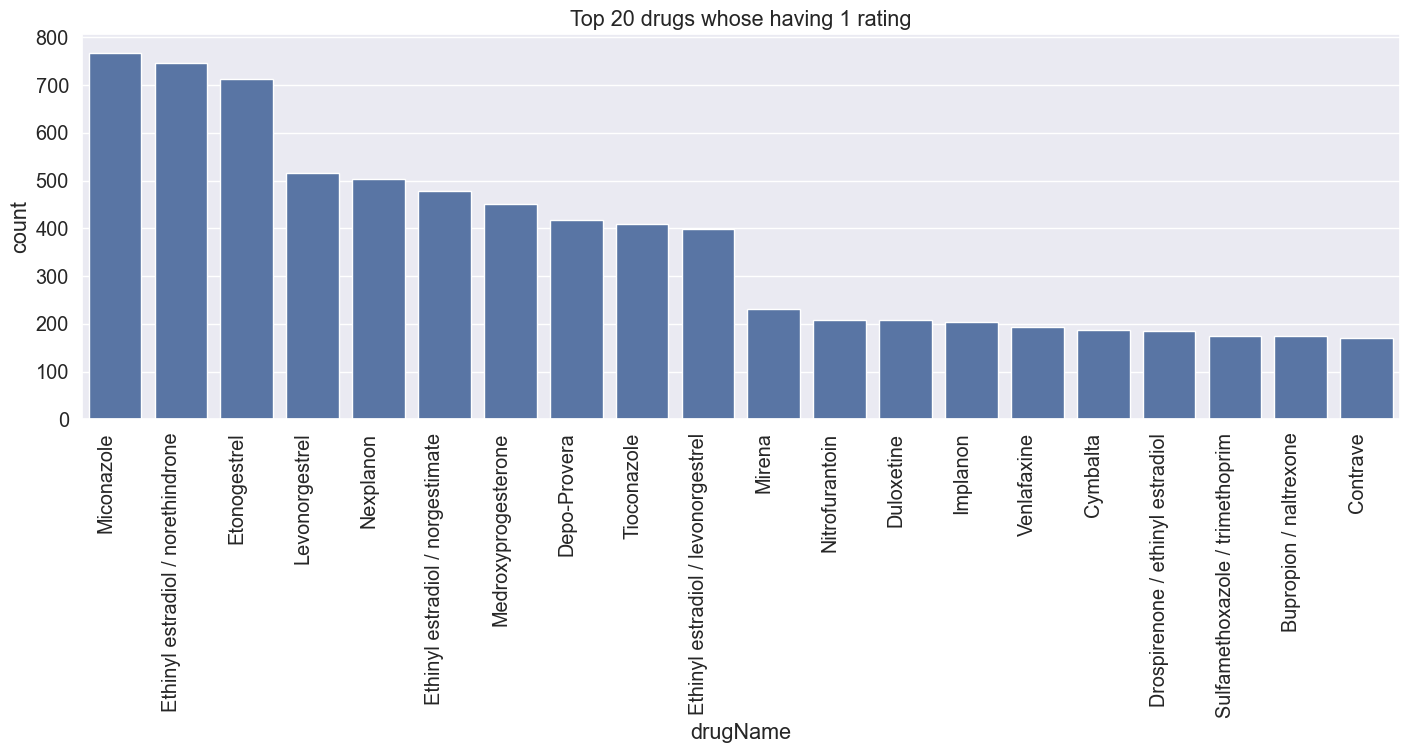

In [20]:
top_drugs_1 = df[df['rating'] == 1]['drugName'].value_counts().head(20)
bar=sns.barplot(top_drugs_1)
bar.set_title('Top 20 drugs whose having 1 rating')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [8, 8]

C:\Users\91939\AppData\Local\Temp\ipykernel_18776\4106974381.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


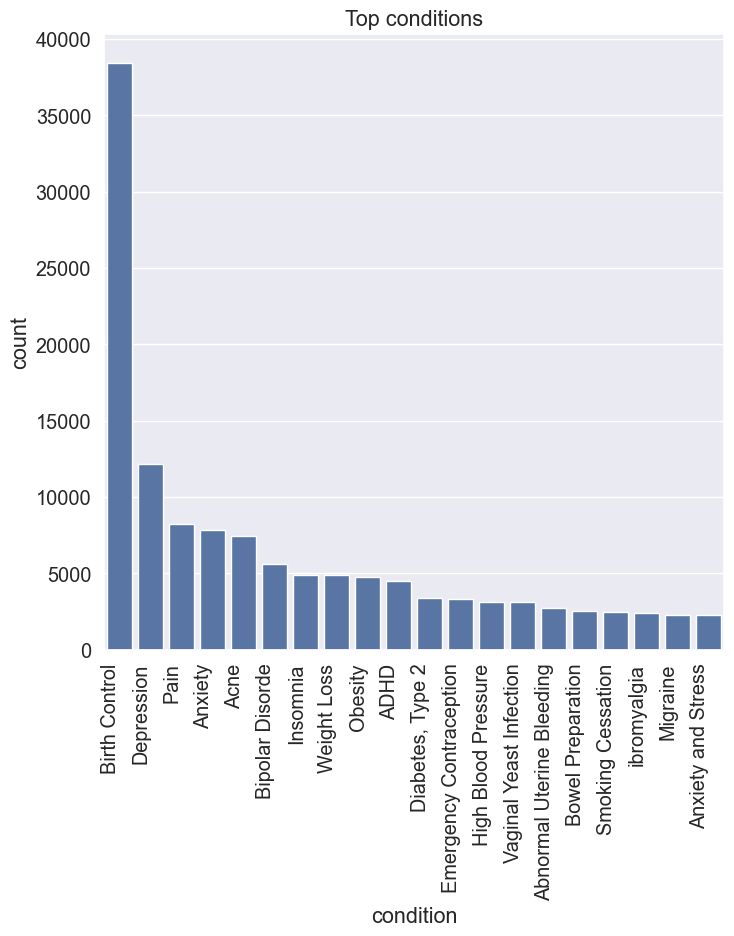

In [21]:
top_conditions = df['condition'].value_counts().head(20)
bar=sns.barplot(top_conditions)
bar.set_title('Top conditions')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [5, 5]

### visualizing as per date

In [22]:
df['date'] = pd.to_datetime(df['date'])

C:\Users\91939\AppData\Local\Temp\ipykernel_18776\3532345252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [23]:
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day

In [24]:
df.head(2)

,uniqueID,drugName,condition,review,rating,date,usefulCount,year,month,day
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,2012,5,20
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,2010,4,27


Text(0.5, 1.0, 'Mean rating in a year')

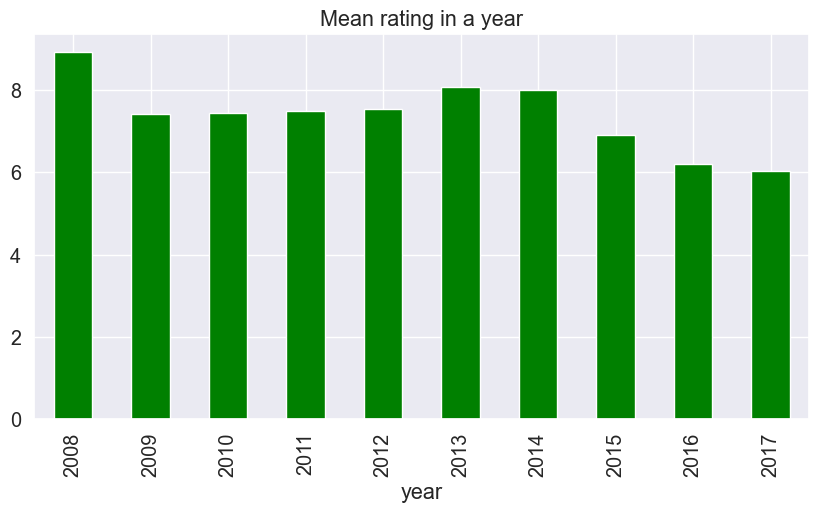

In [25]:
rating=df.groupby('year')['rating'].mean()
rating.plot(kind='bar',figsize=(10,5),color='green')
plt.title('Mean rating in a year')

Text(0.5, 1.0, 'Mean rating in a month')

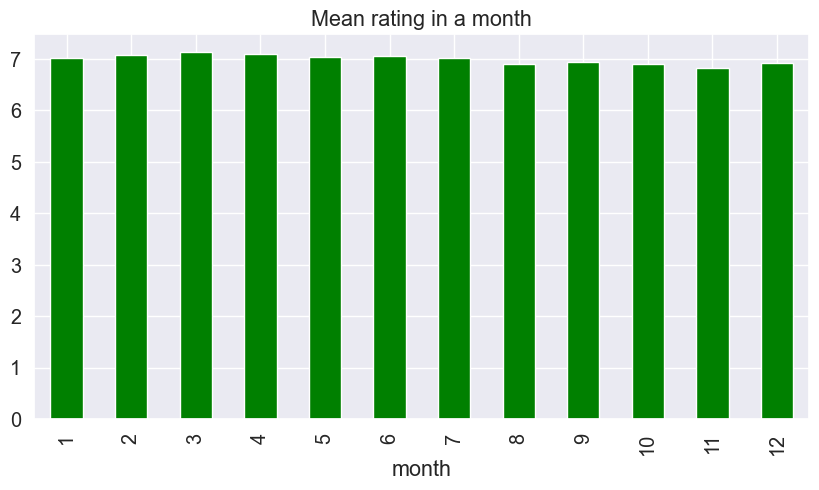

In [26]:
rating=df.groupby('month')['rating'].mean()
rating.plot(kind='bar',figsize=(10,5),color='green')
plt.title('Mean rating in a month')

Text(0.5, 1.0, 'Mean rating in a day')

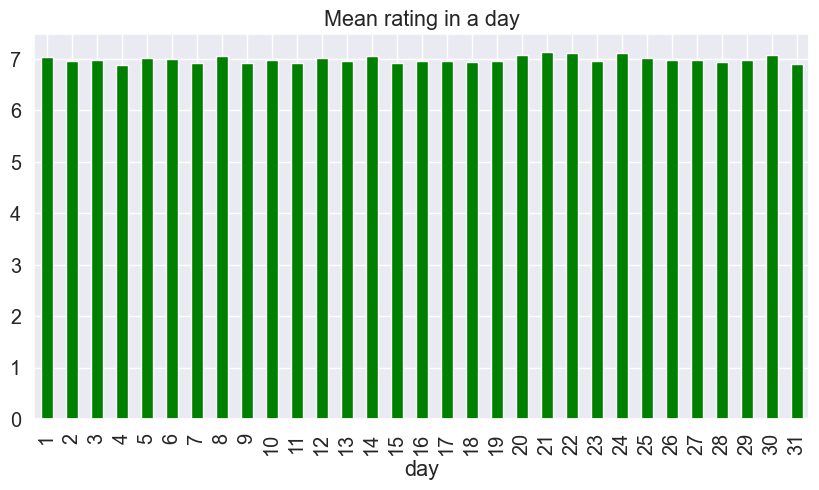

In [27]:
rating=df.groupby('day')['rating'].mean()
rating.plot(kind='bar',figsize=(10,5),color='green')
plt.title('Mean rating in a day')

As we seen the data is distributed equally across the year, month and day. So no need of date column

### Usefull count visualization

In [28]:
df["usefulCount"].describe()

count    215063.000000
mean         28.001004
std          36.346069
min           0.000000
25%           6.000000
50%          16.000000
75%          36.000000
max        1291.000000
Name: usefulCount, dtype: float64

As we see the stdev is so high and the data distribution is so large. So normalizing it will helpfull

In [29]:
df['usefulCount'].nunique()

397

C:\Users\91939\AppData\Local\Temp\ipykernel_18776\2665249276.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["usefulCount"],color="green")


Text(0.5, 1.0, 'Distribution of usefulCount')

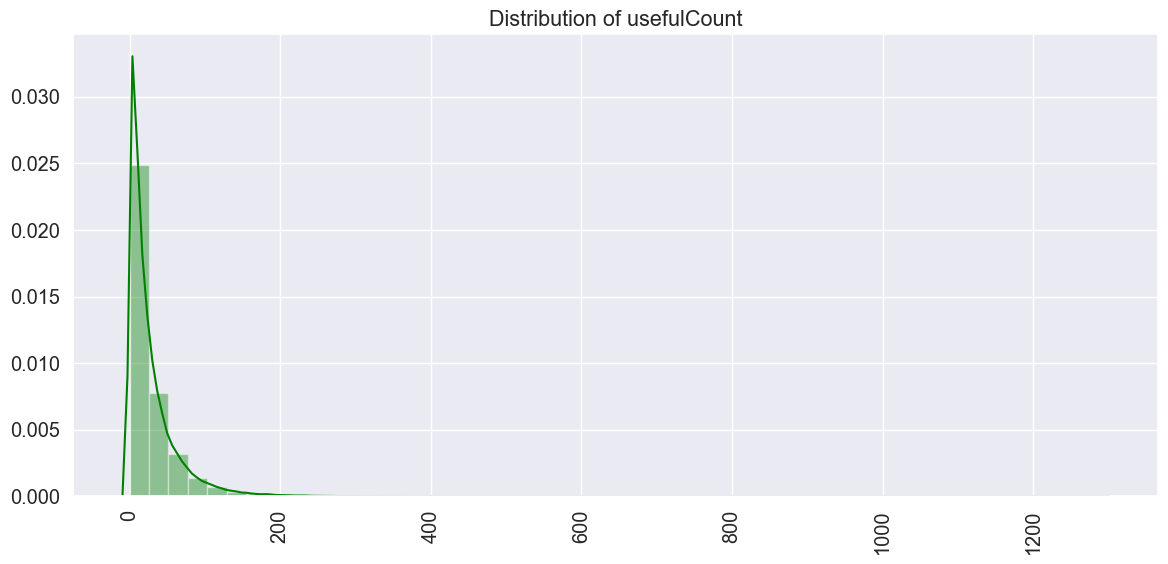

In [30]:
plt.figure(figsize=(14,6))
sns.distplot(df["usefulCount"],color="green")
plt.xticks(rotation='vertical')
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.title("Distribution of usefulCount")

## Text preprocessing

#### Droping null values

In [31]:
df=df.dropna(how="any", axis=0)

In [32]:
import re
def process(text):
    cleaned_text = re.sub(re.compile('<.*?>'), '', text) #removes html tags
    cleaned_text = cleaned_text.lower() #lowers the data
    cleaned_text = cleaned_text.replace(r'[^\w\d\s]',' ') #removes the special characters
    cleaned_text = cleaned_text.replace(r'[^\x00-\x7F]+',' ') # remove all non aschi values
    cleaned_text = cleaned_text.strip() #removes trailing and leading spaces
    cleaned_text = cleaned_text.replace(r'\s+',' ') # replace multiple spaces with single one
    cleaned_text = cleaned_text.replace(r'\.{2,}', ' ') # replace multiple . with single
    cleaned_text = cleaned_text.replace("&#039;", "") #remove repeating pattern
    
    return cleaned_text

### condition series preprocessing

In [33]:
df['condition'] = df['condition'].apply(process)

In [34]:
df['review'] = df['review'].apply(process)

In [35]:
df.sample(20)

,uniqueID,drugName,condition,review,rating,date,usefulCount,year,month,day
32831,72765,Ethinyl estradiol / norethindrone,birth control,"""i love it! i had irregular periods that laste...",10,2015-08-22,4,2015,8,22
74877,44623,Asacol,lymphocytic colitis,"""i am newly diagnosed with lc, i am 38 years o...",8,2011-02-04,23,2011,2,4
21551,171043,Quetiapine,bipolar disorde,"""my son has recently been taking just seroguel...",8,2008-03-27,62,2008,3,27
38406,81431,Yaz,birth control,"""i took yaz for 4 years and loved it up until ...",6,2011-08-09,2,2011,8,9
62155,160700,Buspirone,anxiety,"""ive had a great experience with buspar 20 mg ...",10,2012-08-24,87,2012,8,24
18881,162749,Cefdinir,otitis media,"""my 11 year old son got put on this drug for e...",1,2017-01-17,8,2017,1,17
149364,190160,Phenytek,seizures,"""i had my first ever seizure on 8/4/93; one da...",10,2015-02-23,8,2015,2,23
49772,188229,ParaGard,birth control,"""2 years with the paragard iud.\r\nside effect...",2,2017-10-05,4,2017,10,5
136812,168957,Vilazodone,depression,"""female, age 55. chronic dysthymia with episod...",5,2012-09-25,10,2012,9,25
16674,200163,Varenicline,smoking cessation,"""i smoked for 50+ years. took it for one week...",10,2015-02-14,26,2015,2,14


After doing the preprocessing, in some reviews we find \r, \n and emojis and @amp for and . So remove them also

In [36]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    "]+",
    flags=re.UNICODE,
)

In [37]:
df['review'] = (df['review'].str.replace(r'[\n\r]+', ' ', regex=True).str.replace(emoji_pattern, '', regex=True))

In [39]:
df['review'] = df['review'].str.replace('&amp;', 'and', regex=True)

In [40]:
df.sample(20)

,uniqueID,drugName,condition,review,rating,date,usefulCount,year,month,day
77184,75075,Nitrofurantoin,bladder infection,"""macrobid caused me to have diarrhea.""",1,2009-03-01,9,2009,3,1
64622,229581,Lurasidone,bipolar disorde,"""diagnosed 20 years ago with bipolar 1. stru...",8,2014-12-28,73,2014,12,28
14413,76953,Lorcaserin,obesity,"""just started on belviq a week ago and im so...",10,2015-05-19,21,2015,5,19
47493,217749,Strattera,adhd,"""hey, im a 20 y/o medical assistant (internal ...",4,2016-03-21,18,2016,3,21
29432,32336,Lisinopril,high blood pressure,"""i started 10 mg once a day 2 weeks ago for hb...",2,2016-05-12,25,2016,5,12
18318,175674,Levaquin,sinusitis,"""do not use this drug!!! i was prescribed lava...",1,2017-06-22,14,2017,6,22
109187,174756,Dulera,"asthma, maintenance","""i was just prescribed dulera today and notice...",2,2013-04-29,29,2013,4,29
147048,147481,Alprazolam,panic disorde,"""i have been on xanax (alprazolam) for over 10...",10,2009-10-08,20,2009,10,8
138911,63236,Citric acid / magnesium oxide / sodium picosul...,bowel preparation,"""1pm procedure tuesday, so clear liquid fast m...",10,2016-03-22,6,2016,3,22
9580,18252,Ethinyl estradiol / etonogestrel,birth control,"""i been on nuva ring for 2 months. i love the ...",8,2009-04-06,6,2009,4,6


Now the review and conditions looks good

## Feature transformation